# Système de Filtrage de CV (Resume Screener) avec ML

In [ ]:
!pip install pymupdf spacy scikit-learn
!python -m spacy download fr_core_news_sm

  Using cached https://github.com/explosion/spacy-models/releases/download/fr_core_news_sm-3.8.0/fr_core_news_sm-3.8.0-py3-none-any.whl (16.3 MB)
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import fitz  # PyMuPDF
import re
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nlp = spacy.load('fr_core_news_sm')

def clean_text(text):
    # Nettoyage de base
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^a-zA-ZÀ-ÿ0-9\s]', '', text)
    text = text.lower()
    return text

def extract_text_from_pdf(pdf_path):
    doc = fitz.open(pdf_path)
    text = ""
    for page in doc:
        text += page.get_text()
    return text

print('Fonctions de base initialisées.')

Fonctions de base initialisées.


### Prétraitement Avancé (NLP)
Nous allons créer une fonction qui lemmatise le texte et retire les mots vides (stop words) pour ne garder que le contenu sémantique.

In [ ]:
def preprocess_nlp(text):
    # Nettoyage initial
    text = clean_text(text)
    # Analyse spaCy
    doc = nlp(text)
    # Lemmatisation et retrait des stop words / ponctuation
    tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct and len(token.text) > 2]
    return " ".join(tokens)

# Exemple d'utilisation
test_text = "Je suis un ingénieur en informatique avec de l'expérience en Python et Machine Learning."
print(f"Original: {test_text}")
print(f"Prétraité: {preprocess_nlp(test_text)}")

Original: Je suis un ingénieur en informatique avec de l'expérience en Python et Machine Learning.
Prétraité: ingénieur informatique lexpérience python machine learning


### Extraction des Compétences (Skill Extraction)
Nous définissons une liste de compétences cibles et utilisons spaCy pour les repérer dans le texte.

In [ ]:
from spacy.matcher import PhraseMatcher

def extract_skills(text, skills_list):
    matcher = PhraseMatcher(nlp.vocab, attr='LOWER')
    patterns = [nlp.make_doc(skill) for skill in skills_list]
    matcher.add("SKILLS", patterns)

    doc = nlp(text)
    matches = matcher(doc)

    found_skills = set()
    for match_id, start, end in matches:
        found_skills.add(doc[start:end].text.lower())

    return list(found_skills)

# Liste de test
skills_db = ['python', 'machine learning', 'sql', 'tableau', 'informatique', 'java', 'scikit-learn']

sample_resume = "Ingénieur informatique spécialisé en Python et Machine Learning."
extracted = extract_skills(sample_resume, skills_db)
print(f"Compétences détectées : {extracted}")

Compétences détectées : ['python', 'informatique', 'machine learning']


### Comparaison et Scoring
Nous utiliserons la similarité cosinus pour classer les candidats par rapport à la description de poste.

In [ ]:
def rank_candidates(job_description, resumes_list):
    documents = [clean_text(job_description)] + [clean_text(res) for res in resumes_list]
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(documents)

    # Calcul de la similarité entre la JD (index 0) et les CV
    scores = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:]).flatten()
    return scores

### Analyse de la Description de Poste
Cette section permet d'extraire les éléments clés d'une offre d'emploi pour servir de référence au scoring.

In [ ]:
def parse_job_description(jd_text, skills_db):
    # Nettoyage et prétraitement
    cleaned_jd = preprocess_nlp(jd_text)
    # Extraction des compétences spécifiques
    required_skills = extract_skills(jd_text, skills_db)

    return {
        "clean_text": cleaned_jd,
        "required_skills": required_skills
    }

# Exemple de JD
job_desc_example = """
Nous recherchons un Data Scientist maîtrisant Python et SQL.
Une expérience avec Scikit-learn et le Machine Learning est indispensable.
"""

parsed_jd = parse_job_description(job_desc_example, skills_db)
print(f"Compétences requises identifiées : {parsed_jd['required_skills']}")

Compétences requises identifiées : ['python', 'sql', 'scikit-learn', 'machine learning']


### Système de Scoring Final
Cette fonction regroupe tout : calcul de similarité textuelle et analyse des compétences manquantes.

In [ ]:
def score_resumes(job_description, resumes_list, skills_db, weights=None):
    parsed_jd = parse_job_description(job_description, skills_db)
    jd_vector_text = parsed_jd['clean_text']
    required_skills = set(parsed_jd['required_skills'])

    clean_resumes = [preprocess_nlp(res) for res in resumes_list]

    all_docs = [jd_vector_text] + clean_resumes
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(all_docs)
    similarity_scores = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:]).flatten()

    results = []
    for i, score in enumerate(similarity_scores):
        candidate_skills = set(extract_skills(resumes_list[i], skills_db))
        missing = required_skills - candidate_skills

        # Calcul du bonus de poids pour les compétences
        skill_score = 0
        if weights:
            total_weight = sum(weights.values())
            matched_weight = sum(weights.get(s, 1) for s in candidate_skills if s in required_skills)
            skill_score = (matched_weight / total_weight) if total_weight > 0 else 0
        else:
            skill_score = (len(candidate_skills & required_skills) / len(required_skills)) if required_skills else 0

        # Score final combiné (50% texte, 50% compétences clés)
        final_score = (score * 0.5) + (skill_score * 0.5)

        results.append({
            "candidate_id": f"Candidat {i+1}",
            "match_score": round(final_score * 100, 2),
            "found_skills": list(candidate_skills),
            "missing_skills": list(missing)
        })

    return sorted(results, key=lambda x: x['match_score'], reverse=True)

# Placeholder for resumes_test - you would replace these with actual resume texts
resumes_test = [
    "Développeur Python avec expérience en Machine Learning et SQL.",
    "Chef de projet avec compétences en Python et gestion d'équipes.",
    "Analyste de données junior, maîtrise Excel et Tableau."
]

# Exemple avec poids : Python et Machine Learning sont plus importants
weights = {'python': 3, 'machine learning': 3, 'sql': 1}
final_rankings = score_resumes(job_desc_example, resumes_test, skills_db, weights=weights)


# Résultats du Classement
Voici comment le système classe les candidats et identifie les lacunes par rapport à la description de poste.

In [ ]:
# Exécution finale et affichage formaté
results = score_resumes(job_desc_example, resumes_test, skills_db)

print(f"CLASSEMENT DES CANDIDATS POUR : \n{job_desc_example.strip()}\n")

for i, res in enumerate(results):
    print(f"Rang {i+1} : Candidat {res['candidate_id']}")
    print(f"Score de compatibilité : {res['match_score']}%")
    print(f"Compétences acquises : {', '.join(res['found_skills']) if res['found_skills'] else 'Aucune'}")
    if res['missing_skills']:
        print(f"Compétences manquantes : {', '.join(res['missing_skills'])}")
    else:
        print("Profil complet pour les compétences recherchées.")
    print("-" * 30)

CLASSEMENT DES CANDIDATS POUR : 
Nous recherchons un Data Scientist maîtrisant Python et SQL.
Une expérience avec Scikit-learn et le Machine Learning est indispensable.

Rang 1 : Candidat Candidat 1
Score de compatibilité : 62.09%
Compétences acquises : python, sql, machine learning
Compétences manquantes : scikit-learn
------------------------------
Rang 2 : Candidat Candidat 2
Score de compatibilité : 15.44%
Compétences acquises : python
Compétences manquantes : sql, scikit-learn, machine learning
------------------------------
Rang 3 : Candidat Candidat 3
Score de compatibilité : 0.0%
Compétences acquises : tableau
Compétences manquantes : python, sql, scikit-learn, machine learning
------------------------------


### Identification des Lacunes de Compétences
Ce tableau récapitule les compétences manquantes pour chaque candidat afin de faciliter la prise de décision.

In [ ]:
import pandas as pd

# Transformation des résultats en DataFrame pour une meilleure visibilité
df_gaps = pd.DataFrame(results)
df_gaps = df_gaps[['candidate_id', 'match_score', 'found_skills', 'missing_skills']]

# Affichage du tableau des lacunes
print("Analyse comparative des compétences :")
display(df_gaps)

Analyse comparative des compétences :


,candidate_id,match_score,found_skills,missing_skills
0,Candidat 1,62.09,"[python, sql, machine learning]",[scikit-learn]
1,Candidat 2,15.44,[python],"[sql, scikit-learn, machine learning]"
2,Candidat 3,0.00,[tableau],"[python, sql, scikit-learn, machine learning]"


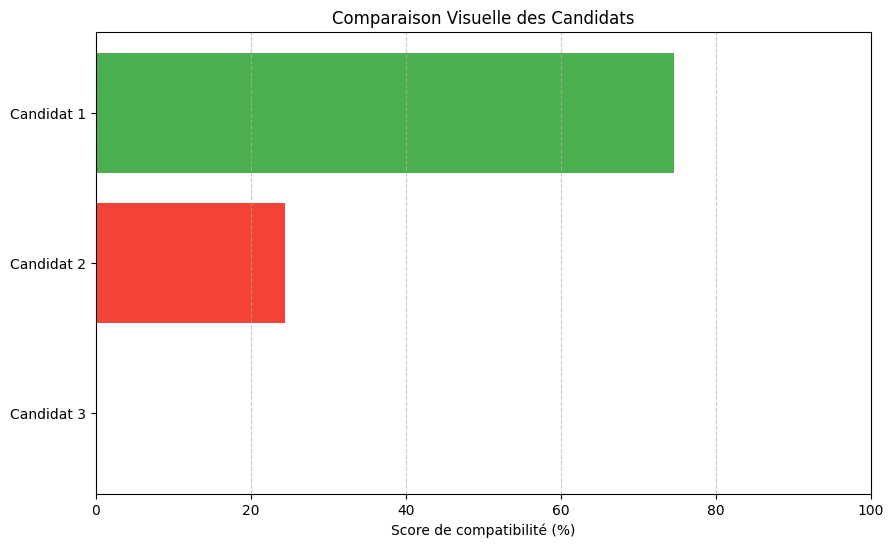

In [ ]:
import matplotlib.pyplot as plt

# Visualisation des scores
names = [res['candidate_id'] for res in final_rankings]
scores = [res['match_score'] for res in final_rankings]

plt.figure(figsize=(10, 6))
colors = ['#4CAF50' if s > 70 else '#FFC107' if s > 40 else '#F44336' for s in scores]
plt.barh(names[::-1], scores[::-1], color=colors[::-1])
plt.xlabel('Score de compatibilité (%)')
plt.title('Comparaison Visuelle des Candidats')
plt.xlim(0, 100)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()